<a href="https://colab.research.google.com/github/PriFranca/pos-eng-dados/blob/main/ETL_3_catalogo_de_produtos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratório de ETL - Atividade 3: Catálogo de Produtos**

# 1. Configuração e Carga de Dados

Nesta etapa, importamos as bibliotecas necessárias e carregamos o arquivo CSV atividade3_catalogo_produtos.csv em um DataFrame do Pandas. Em seguida, realizamos uma exploração inicial para entender a estrutura e identificar problemas de qualidade nos dados.

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o arquivo CSV
file_path = 'atividade3_catalogo_produtos.csv'
df = pd.read_csv(file_path)

# Exibindo informações iniciais do DataFrame
print("### Informações Iniciais do DataFrame:")
df.info()

# Exibindo as primeiras 5 linhas do DataFrame
print("\n### Primeiras 5 Linhas do DataFrame:")
df.head()

### Informações Iniciais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sku             350 non-null    object 
 1   nome_produto    350 non-null    object 
 2   categoria       350 non-null    object 
 3   subcategoria    254 non-null    object 
 4   preco_venda     350 non-null    object 
 5   preco_custo     350 non-null    object 
 6   unidade_medida  350 non-null    object 
 7   estoque         214 non-null    float64
 8   fornecedor      218 non-null    object 
 9   data_cadastro   350 non-null    object 
dtypes: float64(1), object(9)
memory usage: 27.5+ KB

### Primeiras 5 Linhas do DataFrame:


,sku,nome_produto,categoria,subcategoria,preco_venda,preco_custo,unidade_medida,estoque,fornecedor,data_cadastro
0,SKU99482,Calça Jeans \n,VESTUARIO,SUB B,$ 1019.81,"2662,65",PÇ,NaN,NaN,2022-02-28
1,SKU79681,Feijão Preto 1kg \n,alimentos,SUB A,R$ 2848.34,$ 2427.71,KG,-5.0,Forn. A,2023-02-20
2,SKU59002,<p>Notebook Dell Inspiron</p>,eletronicos,NaN,1403,"2748,83",PÇ,-1.0,NaN,2023-12-31
3,SKU45160,Água&nbsp;Sanitária&nbsp;2L,LIMPEZA,sub a,2901,"R$ 1115,30",LT,-1.0,NaN,2023-09-01
4,SKU75901,Sabonete Líquido<br>,Higiene Pessoal,SUB A,BRL 2718.30,241.84,litros,-10.0,NaN,2024-07-19


In [ ]:
# Exibindo estatísticas descritivas para colunas numéricas
print("\n### Estatísticas Descritivas para Colunas Numéricas:")
df.describe()


### Estatísticas Descritivas para Colunas Numéricas:


,estoque
count,214.000000
mean,83.925234
std,147.309498
min,-10.000000
25%,-3.000000
50%,-1.000000
75%,156.500000
max,499.000000


# 2. Limpeza e Padronização dos Dados
 Aplicamos os critérios de limpeza e padronização definidos para cada coluna, garantindo a consistência e a qualidade dos dados.

## 2.1. SKU (sku): Identificar e Tratar Duplicatas
Identificamos SKUs duplicados e mantemos apenas o registro mais recente com base na coluna data_cadastro.

In [ ]:
# Garantir que 'data_cadastro' seja do tipo datetime para ordenação correta
df['data_cadastro'] = pd.to_datetime(df['data_cadastro'], errors='coerce')

# Ordenar por SKU e data_cadastro (mais recente por último)
df_sorted = df.sort_values(by=['sku', 'data_cadastro'], ascending=[True, True])

# Identificar SKUs duplicados antes da remoção (para o entregável de SKUs duplicados)
# duplicated(subset='sku', keep=False) marca todas as ocorrências de um SKU duplicado
duplicated_skus_df = df_sorted[df_sorted.duplicated(subset='sku', keep=False)].copy()

# Manter apenas o registro com a data de cadastro mais recente para cada SKU
df_cleaned = df_sorted.drop_duplicates(subset='sku', keep='last').copy()

# Criar um DataFrame com os SKUs que foram duplicados
skus_duplicados_list = duplicated_skus_df['sku'].unique().tolist()
df_skus_duplicados = pd.DataFrame({'sku': skus_duplicados_list})

print(f"Foram encontrados {len(skus_duplicados_list)} SKUs duplicados. O DataFrame `df_skus_duplicados` foi criado.")

Foram encontrados 29 SKUs duplicados. O DataFrame `df_skus_duplicados` foi criado.


## 2.2. Nome do Produto (nome_produto): Remover Tags HTML, Entidades e Espaços Extras
Removemos tags HTML, entidades HTML (como &nbsp;), caracteres especiais de controle e espaços em excesso do nome do produto.

In [ ]:
def clean_product_name(text):
    if pd.isna(text):
        return text
    text = str(text)
    # Remover tags HTML (ex: <p>, <br>)
    text = re.sub(r'<.*?>', '', text)
    # Remover entidades HTML (ex: &nbsp;)
    text = re.sub(r'&[a-z]+;', '', text)
    # Remover caracteres especiais de controle (ex: ®™, <br> que não foi pego pelo regex anterior)
    text = re.sub(r'[®™]', '', text)
    # Remover espaços extras (início, fim e múltiplos espaços no meio)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_cleaned['nome_produto'] = df_cleaned['nome_produto'].apply(clean_product_name)
print("Coluna 'nome_produto' limpa e padronizada.")

Coluna 'nome_produto' limpa e padronizada.


## 2.3. Categoria (categoria): Padronizar Nomes
Agrupamos variações de categorias para seus nomes padronizados.

In [ ]:
def standardize_category(category):
    if pd.isna(category):
        return 'N/A'
    category = str(category).strip().upper()
    if category in ['ELETRÔNICOS', 'ELETRONICOS', 'ELETRO', 'ELETRÔNICO', 'ELETRONICO']:
        return 'Eletrônicos'
    elif category in ['ALIMENTOS', 'ALIMENTO', 'COMIDA']:
        return 'Alimentos'
    elif category in ['VESTUARIO', 'VESTUÁRIO', 'ROUPAS', 'MODA']:
        return 'Vestuário'
    elif category in ['HIGIENE', 'HIGIENE PESSOAL']:
        return 'Higiene Pessoal'
    elif category in ['LIMPEZA', 'PRODUTOS DE LIMPEZA', 'PRODUTOS LIMPEZA']:
        return 'Limpeza'
    return category # Retorna a categoria original se não houver padronização

df_cleaned['categoria'] = df_cleaned['categoria'].apply(standardize_category)
print("Coluna 'categoria' padronizada.")

Coluna 'categoria' padronizada.


## 2.4. Preços (preco_venda, preco_custo): Converter para Numérico
Removemos símbolos de moeda, ajustamos o separador decimal e convertemos os preços para o tipo numérico com duas casas decimais.

In [ ]:
def clean_price(price):
    if pd.isna(price):
        return 0.00
    price = str(price).replace('R$', '').replace('$', '').replace('BRL', '').replace(',', '.').strip()
    try:
        return round(float(price), 2)
    except ValueError:
        return 0.00

df_cleaned['preco_venda'] = df_cleaned['preco_venda'].apply(clean_price)
df_cleaned['preco_custo'] = df_cleaned['preco_custo'].apply(clean_price)
print("Colunas de preço ('preco_venda', 'preco_custo') limpas e convertidas para numérico.")

Colunas de preço ('preco_venda', 'preco_custo') limpas e convertidas para numérico.


## 2.5. Unidade de Medida (unidade_medida): Padronizar Nomes
Padronizamos as unidades de medida para um conjunto de valores consistentes.

In [ ]:
def standardize_unit(unit):
    if pd.isna(unit):
        return 'N/A'
    unit = str(unit).strip().upper()
    if unit in ['UN', 'UNIDADE', 'PÇ', 'PECA', '1']:
        return 'UN'
    elif unit in ['KG', 'QUILOS', 'KILO']:
        return 'KG'
    elif unit in ['G', 'GRAMAS', 'GR']:
        return 'G'
    elif unit in ['ML', 'MILILITROS']:
        return 'ML'
    elif unit in ['L', 'LITROS', 'LT']:
        return 'L'
    elif unit in ['PAR', 'PARES']:
        return 'PAR'
    return unit # Retorna a unidade original se não houver padronização

df_cleaned['unidade_medida'] = df_cleaned['unidade_medida'].apply(standardize_unit)
print("Coluna 'unidade_medida' padronizada.")

Coluna 'unidade_medida' padronizada.


## 2.6. Estoque (estoque): Converter para Inteiro e Tratar Valores Inválidos
Convertemos a coluna de estoque para o tipo inteiro, tratando valores negativos, nulos ou textuais como 0.

In [ ]:
def clean_stock(stock):
    if pd.isna(stock) or str(stock).strip().upper() == 'NULL':
        return 0
    try:
        # Converte para float primeiro para lidar com strings como '-5.0' antes de converter para int
        stock_int = int(float(str(stock).strip()))
        return max(0, stock_int) # Garante que o estoque não seja negativo
    except ValueError:
        return 0

df_cleaned['estoque'] = df_cleaned['estoque'].apply(clean_stock)
print("Coluna 'estoque' limpa e convertida para inteiro.")

Coluna 'estoque' limpa e convertida para inteiro.


# 3. Entregáveis e Saída
Geramos os entregáveis solicitados: o DataFrame de SKUs duplicados, o arquivo CSV com o catálogo limpo e um gráfico de contagem de produtos por categoria.

## 3.1. SKUs Duplicados
Exibimos a lista de SKUs que foram identificados como duplicados e, portanto, tiveram registros descartados (mantendo o mais recente).

In [ ]:
print("\n### SKUs Duplicados Encontrados (apenas o SKU):")
if not df_skus_duplicados.empty:
    print(df_skus_duplicados)
else:
    print("Nenhum SKU duplicado foi encontrado.")


### SKUs Duplicados Encontrados (apenas o SKU):
         sku
0   SKU15971
1   SKU30207
2   SKU33097
3   SKU38108
4   SKU38913
5   SKU39105
6   SKU42409
7   SKU47994
8   SKU49595
9   SKU50437
10  SKU56936
11  SKU60960
12  SKU65022
13  SKU65328
14  SKU70429
15  SKU75901
16  SKU76277
17  SKU77237
18  SKU79681
19  SKU79936
20  SKU80388
21  SKU85063
22  SKU86756
23  SKU90657
24  SKU91153
25  SKU91583
26  SKU92517
27  SKU98057
28  SKU99482


## 3.2. Salvar Catálogo Limpo
Salvamos o DataFrame df_cleaned em um novo arquivo CSV chamado catalogo_limpo.csv.

In [ ]:
output_file_path = 'catalogo_limpo.csv'
df_cleaned.to_csv(output_file_path, index=False)
print(f"\nCatálogo de produtos limpo salvo em: {output_file_path}")


Catálogo de produtos limpo salvo em: catalogo_limpo.csv


## 3.3. Gráfico de Contagem de Produtos por Categoria
Geramos um gráfico de barras para visualizar a distribuição de produtos por categoria padronizada.

/tmp/ipykernel_20589/949549819.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, y='categoria', order=df_cleaned['categoria'].value_counts().index, palette='viridis')


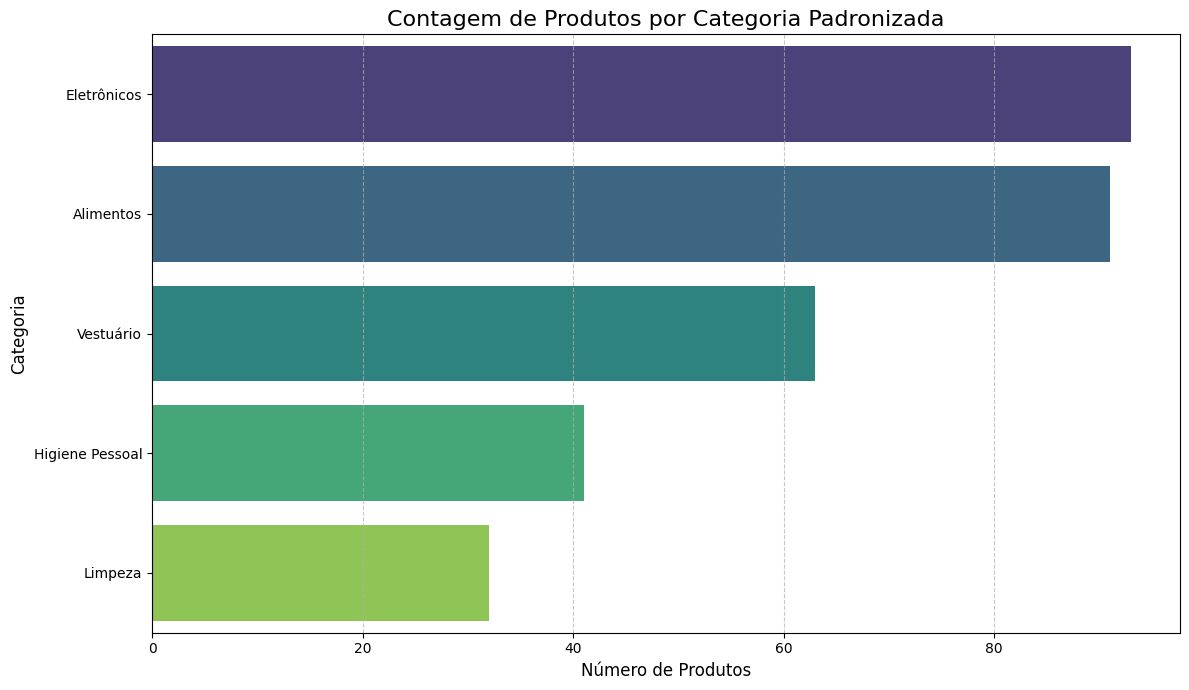

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df_cleaned, y='categoria', order=df_cleaned['categoria'].value_counts().index, palette='viridis')
plt.title('Contagem de Produtos por Categoria Padronizada', fontsize=16)
plt.xlabel('Número de Produtos', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()